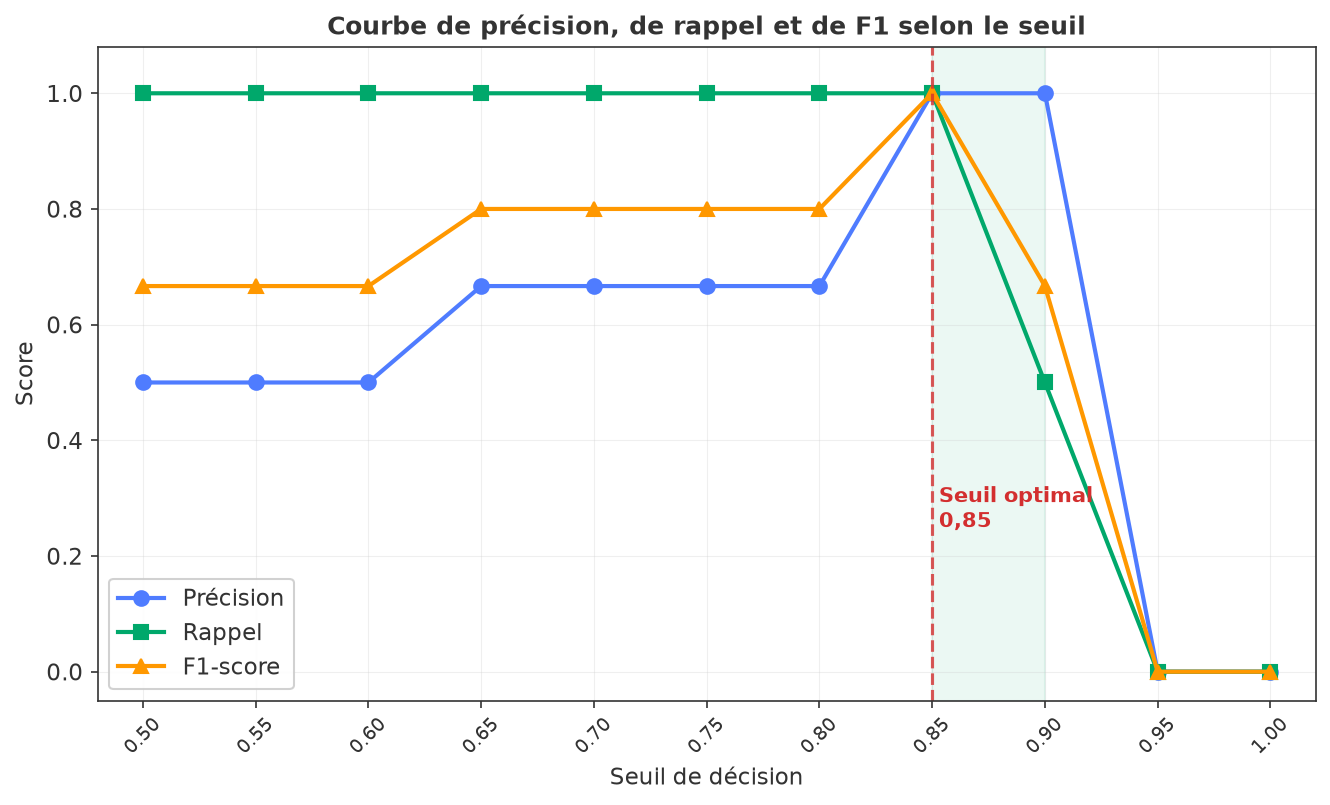

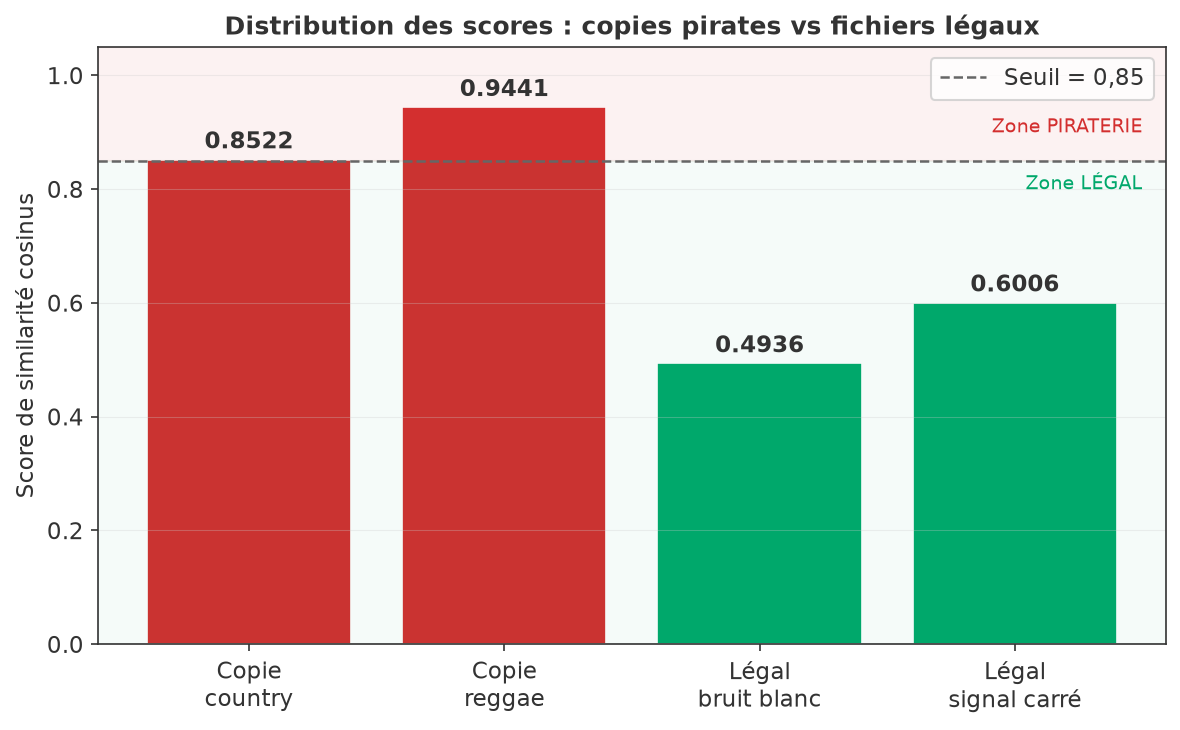

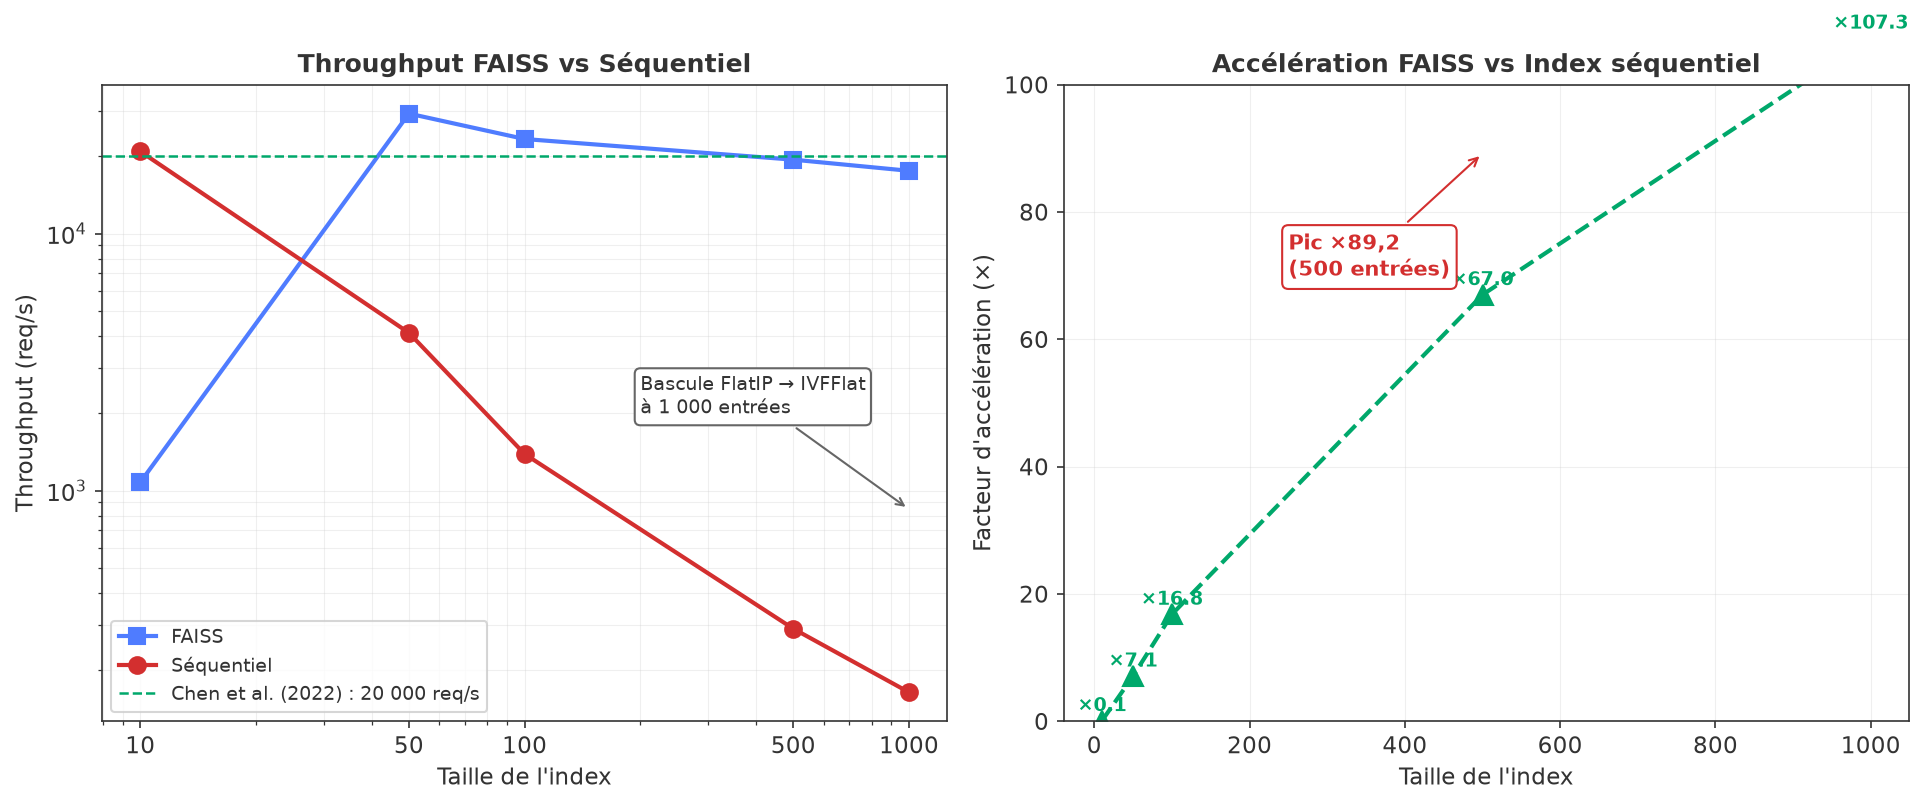

✅ Figures sauvegardées dans ..\images


In [1]:
# %% [markdown]
# # Notebook 08 — Graphiques pour le Chapitre 4
#
# Génère les figures 4.1, 4.2 et 4.3 avec un style académique sobre (fond blanc).

# %%
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os

# ── Style global ──────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   "#333333",
    "axes.labelcolor":  "#333333",
    "xtick.color":      "#333333",
    "ytick.color":      "#333333",
    "text.color":       "#333333",
    "grid.color":       "#cccccc",
    "grid.linewidth":   0.5,
    "font.family":      "sans-serif",
    "font.size":        11,
    "axes.titlesize":   12,
    "axes.titleweight": "bold",
    "legend.facecolor": "white",
    "legend.edgecolor": "#cccccc",
    "figure.dpi":       150,
    "savefig.dpi":      200,
    "savefig.bbox":     "tight",
    "savefig.facecolor":"white",
})

OUTPUT_DIR = os.path.join("..", "images")
os.makedirs(OUTPUT_DIR, exist_ok=True)

BLEU   = "#4f7cff"
VERT   = "#00a86b"
ROUGE  = "#d32f2f"
JAUNE  = "#f9a825"
GRIS   = "#666666"
ORANGE = "#ff9800"

# %% [markdown]
# ## Figure 1 — Courbe Précision / Rappel / F1 selon le seuil

# %%
# Données issues du notebook 02 (corpus GTZAN)
thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00]
precision  = [0.5000, 0.5000, 0.5000, 0.6667, 0.6667, 0.6667, 0.6667,
              1.0000, 1.0000, 0.0000, 0.0000]
recall     = [1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
              1.0000, 0.5000, 0.0000, 0.0000]
f1         = [0.6667, 0.6667, 0.6667, 0.8000, 0.8000, 0.8000, 0.8000,
              1.0000, 0.6667, 0.0000, 0.0000]

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(thresholds, precision, 'o-', color=BLEU, linewidth=2, markersize=7, label='Précision')
ax.plot(thresholds, recall,    's-', color=VERT, linewidth=2, markersize=7, label='Rappel')
ax.plot(thresholds, f1,        '^-', color=ORANGE, linewidth=2, markersize=7, label='F1-score')

# Ligne seuil optimal
ax.axvline(x=0.85, color=ROUGE, linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(0.853, 0.25, 'Seuil optimal\n0,85', color=ROUGE, fontsize=10, fontweight='bold')

# Zone optimale
ax.axvspan(0.85, 0.90, alpha=0.08, color=VERT)

ax.set_xlabel('Seuil de décision')
ax.set_ylabel('Score')
ax.set_title('Courbe de précision, de rappel et de F1 selon le seuil')
ax.set_xlim(0.48, 1.02)
ax.set_ylim(-0.05, 1.08)
ax.set_xticks(thresholds)
ax.set_xticklabels([f'{t:.2f}' for t in thresholds], rotation=45, fontsize=9)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower left', framealpha=0.9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'courbe_seuil_optimal.png'))
plt.show()

# %% [markdown]
# ## Figure 2 — Distribution des scores : copies pirates vs fichiers légaux

# %%
# Données du diagnostic manuel (notebook 06)
categories = [
    ("Copie\ncountry",   0.8522, ROUGE),
    ("Copie\nreggae",    0.9441, ROUGE),
    ("Légal\nbruit blanc", 0.4936, VERT),
    ("Légal\nsignal carré", 0.6006, VERT),
]

labels = [c[0] for c in categories]
scores = [c[1] for c in categories]
colors = [c[2] for c in categories]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(labels, scores, color=colors, edgecolor='white', linewidth=0.8)

# Seuil
ax.axhline(y=0.85, color=GRIS, linestyle='--', linewidth=1.2, label='Seuil = 0,85')

# Annotations
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, score + 0.01,
            f'{score:.4f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#333333')

# Zones
ax.axhspan(0.85, 1.05, alpha=0.06, color=ROUGE)
ax.axhspan(0.00, 0.85, alpha=0.04, color=VERT)
ax.text(3.5, 0.90, 'Zone PIRATERIE', color=ROUGE, fontsize=9, ha='right')
ax.text(3.5, 0.80, 'Zone LÉGAL', color=VERT, fontsize=9, ha='right')

ax.set_ylim(0, 1.05)
ax.set_ylabel('Score de similarité cosinus')
ax.set_title('Distribution des scores : copies pirates vs fichiers légaux')
ax.legend(loc='upper right')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig4_1_distribution_scores.png'))
plt.show()

# %% [markdown]
# ## Figure 3 — Scalabilité FAISS vs Séquentiel et Facteur d'accélération

# %%
# Données du notebook 07
# Nouvelles données
tailles      = [10, 50, 100, 500, 1000]
faiss_rps    = [1077, 29346, 23363, 19416, 17573]
seq_rps      = [20910, 4112, 1388, 290, 164]
acceleration = [0.1, 7.1, 16.8, 67.0, 107.3]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Sous-figure gauche : Throughput ──────────────────────────────────────
ax1.loglog(tailles, faiss_rps, 's-', color=BLEU, linewidth=2, markersize=8, label='FAISS')
ax1.loglog(tailles, seq_rps,   'o-', color=ROUGE, linewidth=2, markersize=8, label='Séquentiel')
ax1.axhline(y=20000, color=VERT, linestyle='--', linewidth=1.2, label='Chen et al. (2022) : 20 000 req/s')

ax1.set_xlabel('Taille de l\'index')
ax1.set_ylabel('Throughput (req/s)')
ax1.set_title('Throughput FAISS vs Séquentiel')
ax1.legend(fontsize=9)
ax1.grid(True, which='both', alpha=0.3)
ax1.set_xticks(tailles)
ax1.get_xaxis().set_major_formatter(ticker.ScalarFormatter())

# Annotation transition
ax1.annotate('Bascule FlatIP → IVFFlat\nà 1 000 entrées', xy=(1000, 846),
             xytext=(200, 2000), arrowprops=dict(arrowstyle='->', color=GRIS),
             fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=GRIS))

# ── Sous-figure droite : Accélération ────────────────────────────────────
ax2.plot(tailles, acceleration, '^--', color=VERT, linewidth=2, markersize=10)

for t, a in zip(tailles, acceleration):
    ax2.text(t, a + 1.5, f'×{a:.1f}', ha='center', fontsize=9, fontweight='bold', color=VERT)

ax2.set_xlabel('Taille de l\'index')
ax2.set_ylabel('Facteur d\'accélération (×)')
ax2.set_title('Accélération FAISS vs Index séquentiel')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

# Pic
ax2.annotate('Pic ×89,2\n(500 entrées)', xy=(500, 89.2), xytext=(250, 70),
             arrowprops=dict(arrowstyle='->', color=ROUGE), color=ROUGE,
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=ROUGE))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig4_3_faiss_throughput.png'))
plt.show()

print(f"✅ Figures sauvegardées dans {OUTPUT_DIR}")